# Importación del Dataset

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import kagglehub
from kagglehub import KaggleDatasetAdapter


F:\Simulación\dataset-tp\.simulacionworkspace\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importo dataset

In [2]:
file_path = "./dataset"

kagglehub.dataset_download( "peterfriedrich1/cicdarknet2020-internet-traffic", output_dir=file_path,force_download=True)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16.0M/16.0M [00:02<00:00, 7.65MB/s]

Extracting files...


'./dataset'

Observamos los datos

In [3]:
datasetRaw = pd.read_csv("./dataset/Darknet.CSV", on_bad_lines='skip')
datasetRaw

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,10.152.152.11-74.125.136.120-49134-443-6,10.152.152.11,49134,74.125.136.120,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,10.152.152.11-173.194.65.127-34697-19305-6,10.152.152.11,34697,173.194.65.127,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1.437765e+15,3.117718e+06,1.437765e+15,1.437765e+15,Non-Tor,AUDIO-STREAMING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141525,10.8.8.246-224.0.0.252-55219-5355-17,10.8.8.246,55219,224.0.0.252,5355,17,22/05/2015 01:55:03 PM,411806,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP
141526,10.8.8.246-224.0.0.252-64207-5355-17,10.8.8.246,64207,224.0.0.252,5355,17,22/05/2015 02:09:05 PM,411574,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP
141527,10.8.8.246-224.0.0.252-61115-5355-17,10.8.8.246,61115,224.0.0.252,5355,17,22/05/2015 02:19:31 PM,422299,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP
141528,10.8.8.246-224.0.0.252-64790-5355-17,10.8.8.246,64790,224.0.0.252,5355,17,22/05/2015 02:29:55 PM,411855,2,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,VPN,VOIP


# Clasificación de datos

### Variables Exógenas

**Variables de datos:**
* Intervalo entre paquetes
* Tiempo de recepción

**Variables de control:**
* ??

**Variable de estado:**
* Conexiones establecidas

**Variable de resultado:**
* Tiempo promedio de recepción de datos
* Velocidad promedio de subida
* Velocidad promedio de bajada
* Paquetes promedios enviados por conexión


## Gráficos de distribuciones

### Distribución de puertos

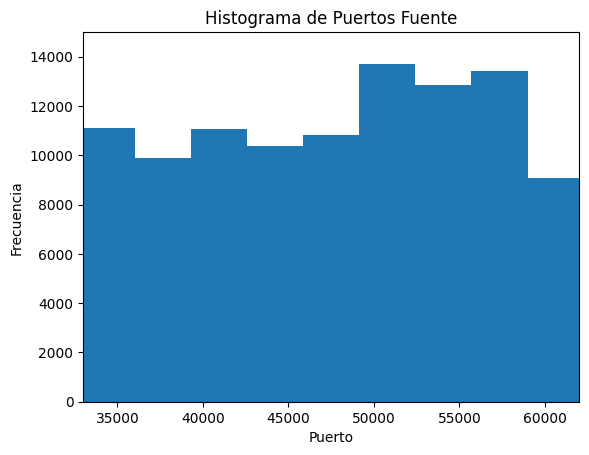

In [10]:
import matplotlib.pyplot as plt

plt.hist(datasetRaw['Src Port'], bins=20)
plt.xlabel('Puerto')
plt.xlim(33000, 62000)
plt.ylabel('Frecuencia')
plt.ylim(0, 15000)
plt.title('Histograma de Puertos Fuente')
plt.show()

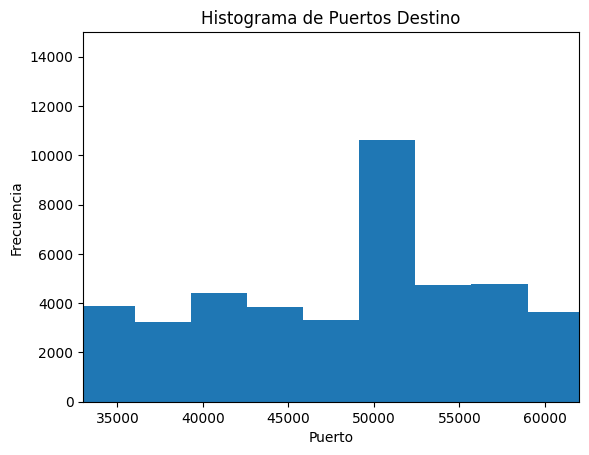

In [11]:
import matplotlib.pyplot as plt

plt.hist(datasetRaw['Dst Port'], bins=20)
plt.xlabel('Puerto')
plt.xlim(33000, 62000)
plt.ylabel('Frecuencia')
plt.ylim(0, 15000)
plt.title('Histograma de Puertos Destino')
plt.show()

In [15]:
dataset_rango = datasetRaw[
    (datasetRaw['Dst Port'] >= 33000) & 
    (datasetRaw['Dst Port'] <= 62000)
]
puerto_mas_frecuente = dataset_rango['Dst Port'].mode()[0]
#El puesto de atención de nuestros eventos será el puerto destino dentro del rango presentado con más conexiones
puerto_mas_frecuente

np.int64(51413)

### Distribución de Protocolos

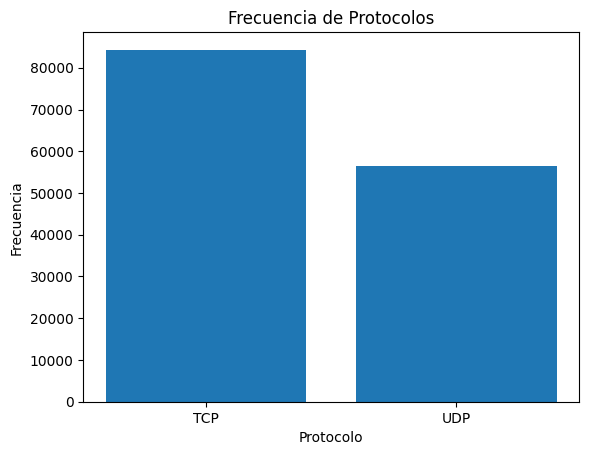

In [6]:
import matplotlib.pyplot as plt

protocol_map = {
    1: 'ICMP',
    6: 'TCP',
    17: 'UDP'
}

datasetRaw['Protocol_label'] = datasetRaw['Protocol'].map(protocol_map)

counts = datasetRaw['Protocol_label'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Protocolo')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de Protocolos')
plt.show()


# Presentación del caso de uso de la simulación EaE

## QoS de los servidores sobre el puerto 51413 (Quality of Service)

En los servidores on-premise de una empresa tecnológica, los usuarios se conectan mediante el puerto 51413 para acceder a los servicios y aplicaciones.

La empresa se encuentra en expansión y necesita saber si requiere invertir en proyectos para distribuir la carga sobre este puerto particular. Para ello haremos una simulación con las siguientes definiciones:

* Evento → llegada de un flujo (Timestamp)
* Servicio → procesamiento del flujo (Flow Duration)
* Cola → Puerto 51413. Se puede entrar de distintas IPs provenientes de un Load Balancer.
* Prioridades:
  + Por protocolo (TCP vs UDP): Priorizaremos el protocolo **UDP** ya que suelen ser los que más rápido despachan sus paquetes.

## Generación del Dataframe

In [22]:
datasetFinal = datasetRaw[
    (datasetRaw['Dst Port']==51413)
    ]

datasetFinal = datasetFinal[['Flow ID','Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol_label','Timestamp','Flow Duration']]
datasetFinal

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol_label,Timestamp,Flow Duration
40509,10.152.152.11-94.111.203.124-33393-51413-6,10.152.152.11,33393,94.111.203.124,51413,TCP,24/02/2016 09:48:19 AM,1275
40525,10.152.152.11-117.217.84.124-40839-51413-6,10.152.152.11,40839,117.217.84.124,51413,TCP,24/02/2016 09:48:31 AM,1670613
40527,10.152.152.11-117.217.84.124-40839-51413-6,10.152.152.11,40839,117.217.84.124,51413,TCP,24/02/2016 09:48:33 AM,182296
40536,10.152.152.11-182.18.177.70-47495-51413-6,10.152.152.11,47495,182.18.177.70,51413,TCP,24/02/2016 09:48:34 AM,552135
40537,10.152.152.11-182.18.177.70-47495-51413-6,10.152.152.11,47495,182.18.177.70,51413,TCP,24/02/2016 09:48:35 AM,87992
...,...,...,...,...,...,...,...,...
102316,131.202.240.87-65.98.72.100-61009-51413-17,131.202.240.87,61009,65.98.72.100,51413,UDP,01/05/2015 11:39:00 AM,54869
123216,10.8.8.130-134.173.128.153-51413-51413-17,10.8.8.130,51413,134.173.128.153,51413,UDP,04/06/2015 09:35:04 AM,279664
123466,110.168.232.198-10.8.8.130-48319-51413-17,110.168.232.198,48319,10.8.8.130,51413,UDP,04/06/2015 09:35:31 AM,5303557
123469,10.8.8.130-91.121.198.25-51413-51413-17,10.8.8.130,51413,91.121.198.25,51413,UDP,04/06/2015 09:34:52 AM,126161


Vamos a ver el rango de tiempo que nos quedó en el dataset para simular...

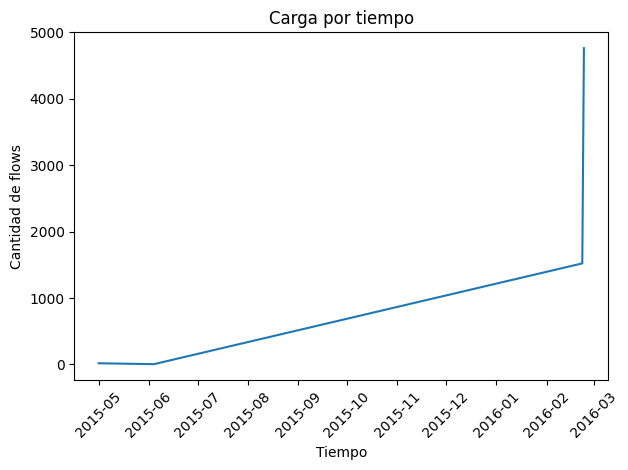

In [24]:
datasetFinal['Timestamp'] = pd.to_datetime(datasetFinal['Timestamp'])

carga_por_dia = datasetFinal.groupby(datasetFinal['Timestamp'].dt.date).size()

carga_por_dia.plot()
plt.xlabel('Tiempo')
plt.ylabel('Cantidad de flows')
plt.title('Carga por tiempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Resultado:** 10 meses (casi un año). Los datos son suficientes.

# Conclusiones